# Network and Spillover Effects 

## 1. Main Business Question

We suppose a compny like Zynga currently has a **single-player mobile game** and wants to introduce a **multiplayer version**.

The main goal is to estimate:

> **How much does the multiplayer version change player revenue?**

The main challenge is the presence of **network effects**.

A player's revenue may depend not only on whether they receive the multiplayer version as a treatment, but also on whether **other players in the same city** receive it.

---

## 2. Population

The experiment contains:

- **36 cities**
- **1,000 users per city**
- **36,000 users in total**

Network effects are assumed to happen mainly **within the same city**.

---

## 3. Case 1: Person-Level Randomization

In this experiment:

- 50% of users receive the multiplayer version.
- 50% remain with the single-player version.
- There are exactly **18,000 treatment users** and **18,000 control users**.

Approximately half of the users in each city are treated.

### Main Problem

Treatment and control users are in the **same city/network**.

Therefore, control users may be affected by treated users.

This creates a **spillover effect**.

For example:

> A control player may benefit because many other players in their city have access to multiplayer.

So the difference between treatment and control may not represent the full treatment effect.

---

## 4. Case 2: City-Level Randomization

In this experiment, entire cities are being randomized.

For example:

- Atlanta → 100% treatment
- Austin → 100% control

Approximately:

- **18 cities receive treatment**
- **18 cities remain control**

### Advantage

Treatment and control users are separated by city.

This reduces contamination from network effects between treatment and control groups.

### Disadvantage

Although there are 36,000 users, the actual randomized units are only:

> **36 cities**

Therefore, the estimate can have:

- Higher variance
- Larger standard errors
- Lower statistical power

---

## 5. Case 3: Two-Stage Randomization

Two-stage randomization combines city-level and person-level randomization.

### Stage 1

Cities are assigned different treatment fractions.

For example:

- Atlanta → 60% treatment
- Austin → 10% treatment
- Chicago → 80% treatment

### Stage 2

Individuals within each city are randomly assigned to treatment according to the city's treatment fraction.

### Advantage

This design allows us to study both:

#### Direct Effect

The effect of receiving the multiplayer version yourself.

#### Spillover Effect

The effect of having more treated users around you in the same city.

Therefore, two-stage randomization is useful when we want to directly measure **network effects**.

---

## 6. Dataset Structure

The dataset contains:

- **36,000 rows**
- **7 columns**

Each row represents one user.

| Column | Description |
|---|---|
| `city` | User's city |
| `treatment_person` | Treatment assignment under person-level randomization |
| `treatment_city` | Treatment assignment under city-level randomization |
| `treatment_twostage` | Treatment assignment under two-stage randomization |
| `outcome_person` | Revenue under person-level randomization |
| `outcome_city` | Revenue under city-level randomization |
| `outcome_twostage` | Revenue under two-stage randomization |

---

## Main Goal of the Project

The overall goal is to compare the three experimental designs and determine:

> **Which experimental design gives the most reliable estimate of the multiplayer game's effect on revenue when network effects are present?**



## Important Note About the Dataset

In a real experiment, the same person or city would **not usually be assigned under all three experimental designs at the same time**.

Normally, we would choose **one experimental design**:

- Person-level randomization
- City-level cluster randomization
- Two-stage randomization

However, this dataset provides the results from all three designs side by side:

- `treatment_person`, `revenue_person`
- `treatment_city`, `revenue_city`
- `treatment_twostage`, `revenue_twostage`

This allows us to compare:

> **What would the results look like under each experimental design?**

So, we can think of the dataset as containing **three parallel hypothetical experiments using the same underlying population of users**.

The purpose is not to say that each user actually participated in all three experiments at once. Instead, the dataset is structured this way so that we can compare how the estimated treatment effect changes depending on the randomization strategy.



## Step1: Person-Level Randomization

For the **person-level randomization**, we want to use:

- `treatment_person`
- `revenue_person`

### 1. Estimate the Treatment Effect

The treatment effect is simply:

$$
\text{Average revenue of treated people}
-
\text{Average revenue of control people}
$$

So:

$$
\hat{\tau}
=
\bar{Y}_{T=1}
-
\bar{Y}_{T=0}
$$

where:

- $\bar{Y}_{T=1}$ = average revenue of treated users
- $\bar{Y}_{T=0}$ = average revenue of control users

---

### 2. Estimate the Standard Error Using Bootstrap

To calculate the **bootstrap standard error** we:

1. Resample the rows **with replacement**.
2. Calculate the treatment effect in the bootstrap sample.
3. Repeat this process at least **2,000 times**.
4. Take the standard deviation of the 2,000 estimated treatment effects.

Therefore:

$$
SE_{bootstrap}
=
SD(\hat{\tau}_1,\hat{\tau}_2,\ldots,\hat{\tau}_{2000})
$$

This standard deviation is the **bootstrap standard error of the estimated treatment effect**.

In [2]:
import pandas as pd
import numpy as np

df = pd.read_csv("Network Effect.csv")

# Treatment effect
treated_mean = df[df["treatment_person"] == 1]["revenue_person"].mean()
control_mean = df[df["treatment_person"] == 0]["revenue_person"].mean()

treatment_effect = treated_mean - control_mean

print("Treatment Effect:", treatment_effect)


#  Bootstraping standard error
B = 2000
bootstrap_effects = []

for i in range(B):

    # sample the same number of rows, with replacement
    sample = df.sample(n=len(df), replace=True)

    treated = sample[sample["treatment_person"] == 1]["revenue_person"].mean()
    control = sample[sample["treatment_person"] == 0]["revenue_person"].mean()

    effect = treated - control

    bootstrap_effects.append(effect)


standard_error = np.std(bootstrap_effects, ddof=1)

print("Bootstrap Standard Error:", standard_error)

Treatment Effect: 3.811934002175377
Bootstrap Standard Error: 0.15298195596713698


The estimated treatment effect is:

$$
\boxed{\hat{\tau} \approx 3.81}
$$

The bootstrap standard error is:

$$
\boxed{SE_{\text{bootstrap}} \approx 0.15}
$$

## So we can say: 

At the **person-level experiment**, treatment increases average revenue by about **3.81 per person**, with a bootstrap standard error of about **0.15**.

At the person-level experiment, treatment increases average revenue by about 3.81 dollar per person, with a bootstrap standard error of about 0.15 dollar.(if we suppose the revenue unit is dollar)

For this analysis, we only use:

- `treatment_person`
- `revenue_person`

We do **not** use `revenue_city` or `revenue_twostage`, because this result refers specifically to the **person-level randomization experiment**.

## Step 2: City level randomization.

The important difference from the previous question is:

**Now the experimental unit is the city, not the person**

So first we convert the 36,000 person-level rows into 36 city-level observations.

For each city, we calculate:

$$ \text{average revenue in that city} $$

Then we compare:

average revenue of treated cities−average revenue of control cities

In [3]:
#  city-level data
city_df = df.groupby("city").agg(
    treatment_city=("treatment_city", "first"),
    revenue_city=("revenue_city", "mean")
).reset_index()


# Treatment effect
treated_mean = city_df[city_df["treatment_city"] == 1]["revenue_city"].mean()
control_mean = city_df[city_df["treatment_city"] == 0]["revenue_city"].mean()

treatment_effect = treated_mean - control_mean

print("Treatment Effect:", treatment_effect)


#  Bootstraping standard error
B = 2000
bootstrap_effects = []

treated_cities = city_df[city_df["treatment_city"] == 1]
control_cities = city_df[city_df["treatment_city"] == 0]

for i in range(B):

    # Resampling cities, not people
    treated_sample = treated_cities.sample(
        n=len(treated_cities),
        replace=True
    )

    control_sample = control_cities.sample(
        n=len(control_cities),
        replace=True
    )

    effect = (
        treated_sample["revenue_city"].mean()
        - control_sample["revenue_city"].mean()
    )

    bootstrap_effects.append(effect)


standard_error = np.std(bootstrap_effects, ddof=1)

print("Bootstrap Standard Error:", standard_error)

Treatment Effect: 2.021323852633831
Bootstrap Standard Error: 3.416652760272407


# City-Level Randomization Results

For the **city-level randomization**, the estimated treatment effect is approximately:

$$
\boxed{\hat{\tau}_{city} \approx \$2.02}
$$

This means that people in treated cities have about **$2.02 higher average revenue per person** than people in control cities.

---

## Bootstrap Standard Error

Because treatment was randomized at the **city level**, we must also bootstrap at the **city level**, not the individual-person level.

The bootstrap procedure is:

1. Resample treated cities **with replacement**.
2. Resample control cities **with replacement**.
3. Calculate the difference in average revenue between the resampled treatment and control cities.
4. Repeat this process many times.
5. Take the standard deviation of the estimated treatment effects.

The bootstrap standard error is approximately:

$$
\boxed{SE_{bootstrap} \approx \$3.4}
$$

The exact value may vary slightly depending on the bootstrap samples.

---

## Why Is the Standard Error So Large?

The standard error is much larger than in the person-level experiment.

Although the dataset contains **36,000 people**, treatment was randomized across only:

$$
\boxed{36\text{ independent randomized cities}}
$$

Therefore, the effective number of independent experimental units is much smaller, resulting in **lower statistical precision and a larger standard error**.

---

## Person-Level vs. City-Level Randomization

The results are:

| Design       | Treatment Effect | Bootstrap SE |
|--------------|-----------------:|-------------:|
| Person-level |            $3.81 |        $0.15 |
| City-level   |            $2.02 |        $3.40 |

These two experimental designs illustrate a **bias–variance tradeoff**.

### Person-Level Randomization

Person-level randomization has **low variance** because thousands of individuals are independently randomized.

Therefore, the estimate is very precise:

$$
SE \approx \$0.15
$$

However, if network effects exist, the estimate may be **biased** because treated and control people are mixed within the same city and may affect each other's outcomes.

Therefore, we would trust the person-level design more when:

> **Spillover or network effects are very small or absent.**

---

### City-Level Randomization

City-level randomization reduces the problem of interference because an entire city is assigned to either treatment or control.

Therefore, treated and control users are not mixed within the same city.

However, the estimate has **high variance** because there are only 36 independent randomized cities.

Therefore, we would trust the city-level design more when:

> **Network effects are strong and cities are reasonably isolated from each other.**

---

## Main Comparison

$$
\boxed{\text{Person level: lower variance, potentially more bias}}
$$

$$
\boxed{\text{City level: lower interference bias, much higher variance}}
$$

### Important Note

We cannot determine the **exact numerical bias** of either estimate just by comparing $$3.81$ and $$2.02$.

To calculate actual bias, we would need to know the **true treatment effect**:

$$
Bias(\hat{\tau}) = E[\hat{\tau}] - \tau
$$

Without knowing $\tau$, we can only discuss which design is **more likely to suffer from bias based on the experimental design**.


# Step 3: Two-Stage Randomization

The **person-level estimate may be biased** when network effects exist because treated and control users can affect each other. The **city-level design reduces this interference bias**, but has much higher variance.

Next, we use **two-stage randomization** to separate the **direct treatment effect** from the **indirect (network/spillover) effect**. This approach can still be biased if our assumptions are wrong, especially the assumptions that the direct effect is constant and that direct and indirect effects are additive.

In reality, the direct effect could vary from city to city because of treatment-effect heterogeneity. For example, cities may differ in user demographics, baseline engagement, income, gaming behavior, market size, device usage, or other covariates. So we could really have:

$$
\alpha_{\text{SF}} \neq \alpha_{\text{LA}} \neq \alpha_{\text{Austin}}
$$

Even if there were no spillovers, different cities could have different treatment effects simply because their populations or environments are different.

There is also a second possibility: the direct effect itself could change with saturation. For example, receiving multiplayer personally may be much more useful when 80% of people around you also have multiplayer than when only 10% do.

So there are two different sources of variation:

$$
\boxed{\text{City heterogeneity: }\alpha_i\text{ differs across cities}}
$$

and

$$
\boxed{\text{Saturation interaction: direct effect itself changes with }p}
$$

This assignment avoids both complications by making the strong assumption that:

$$
\boxed{\alpha \text{ is constant across cities and saturation levels}}
$$

Then, any systematic relationship between the estimated city treatment effect and saturation \(p\) is attributed to the spillover effect \(\beta p\).

So, a better and more realistic approach is:

$$
\tau(p)=\alpha(p)+g(p)
$$

But for simplicity, we use:

$$
\boxed{
\text{Total effect at saturation }p
=
\underbrace{\alpha}_{\text{fixed direct effect}}
+
\underbrace{\beta p}_{\text{changing spillover effect}}
}
$$




We will:

1. Estimate the treatment effect **within each city**.
2. Calculate the **proportion treated** in each city.
3. Plot each city's treatment effect against its treatment proportion.
4. Fit a **straight regression line** to examine how the treatment effect changes as treatment exposure in the city increases.


In [5]:
import matplotlib.pyplot as plt


city_results = []

for city in df["city"].unique():

    city_data = df[df["city"] == city]

    # proportion of the city treated
    saturation = city_data["treatment_twostage"].mean()

    # mean revenue for treated and control people
    treated_mean = city_data[
        city_data["treatment_twostage"] == 1
    ]["revenue_twostage"].mean()

    control_mean = city_data[
        city_data["treatment_twostage"] == 0
    ]["revenue_twostage"].mean()

    # treatment effect within the city
    effect = treated_mean - control_mean

    city_results.append([city, saturation, effect])


city_results = pd.DataFrame(
    city_results,
    columns=["city", "saturation", "treatment_effect"]
)

In [6]:
# fit the straight line

slope, intercept = np.polyfit(
    city_results["saturation"],
    city_results["treatment_effect"],
    1
)

print("Direct effect:", intercept)
print("Spillover slope:", slope)

Direct effect: 2.224087551899528
Spillover slope: 2.696846299838011


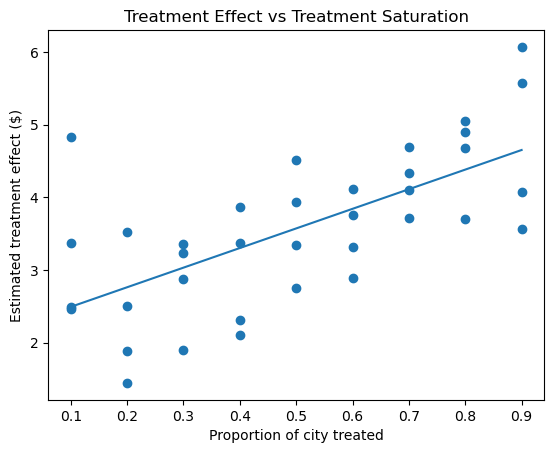

In [7]:
# Plotting

plt.scatter(
    city_results["saturation"],
    city_results["treatment_effect"]
)

x = np.linspace(0.1, 0.9, 100)
y = intercept + slope * x

plt.plot(x, y)

plt.xlabel("Proportion of city treated")
plt.ylabel("Estimated treatment effect ($)")
plt.title("Treatment Effect vs Treatment Saturation")

plt.show()

## Two-Stage Randomization

For each city, we calculated the within-city treatment effect:

$$
\hat{\tau}_{city}
=
\text{mean revenue of treated users}
-
\text{mean revenue of control users}
$$

Then calculated the city's treatment saturation:

$$
p=
\frac{\text{number treated}}{\text{city population}}
$$

For example, one city may have \(p=0.3\) and another \(p=0.8\).

Next, plot:

* **x-axis:** proportion treated in the city, \(p\)
* **y-axis:** estimated treatment effect in that city

Then we fit the linear model:

$$
\hat{\tau}(p)=\alpha+\beta p
$$

Under the simplifying assumptions of this exercise:

* \(\alpha\) represents the **direct effect**
* \(\beta\) represents the additional **spillover/network effect** as treatment saturation increases

---

## Estimated Relationship

For our dataset:

$$
\boxed{\hat{\tau}(p)=2.22+2.70p}
$$

Therefore:

$$
\boxed{\text{Direct effect}\approx \$2.22}
$$

and

$$
\boxed{\text{Indirect/network effect at full saturation}\approx \$2.70}
$$

At full treatment saturation, \(p=1\):

$$
2.22+2.70(1)=\boxed{\$4.92}
$$

So:

| Effect | Estimate |
|---|---:|
| Direct effect | \$2.22 |
| Network contribution at full saturation | \$2.70 |
| Total effect at p = 1 | \$4.92 |

A 10 percentage-point increase in saturation corresponds to approximately:

$$
2.70(0.10)=\$0.27
$$

of additional treatment effect.

---

## Important Point 1: Spillovers May Be Nonlinear

The linear model assumes that spillover increases at a constant rate:

$$
\hat{\tau}(p)=\alpha+\beta p
$$

But real network effects can be nonlinear because of:

* capacity thresholds
* congestion
* positive network effects
* behavioral adaptation
* equilibrium or price changes
* treatment-effect heterogeneity

For example, a social feature may have little value when only 10% of users have it, but become much more valuable when 80% have it.

Therefore:

$$
\boxed{\text{Spillover does not have to increase at a constant rate}}
$$

If the data clearly curves, a polynomial, spline, or separate estimates by saturation level may be more appropriate.

For this project, however, we use a **straight line** because the question explicitly requires it.

---

## Important Point 2: The Direct Effect Is Extrapolated

We do not observe a treated-versus-control comparison at:

$$
p=0
$$

because if 0% of a city is treated, there are no treated users.

Instead, we estimate treatment effects at positive saturation levels and fit:

$$
\hat{\tau}(p)=2.22+2.70p
$$

Then we extend the regression line back to \(p=0\).

Therefore:

$$
\boxed{2.22}
$$

is not directly observed. It is an **extrapolated hypothetical direct effect**.

Its interpretation is:

> What would be the effect of treating one person if essentially nobody else around that person were treated?

So \(p=0\) should be interpreted conceptually as:

> Treat one individual while keeping almost everyone else in control.

---

## What If There Is No Spillover?

If there is no spillover effect, treatment saturation should not change the treatment effect.

Then:

$$
\beta=0
$$

and:

$$
\tau(p)=\alpha
$$

So the graph should be approximately flat:

$$
\boxed{\text{No spillover} \Rightarrow \text{flat line}}
$$


$$
\boxed{\text{Total effect}=\text{Direct effect}=\text{Treatment effect}}
$$


Under the simplifying assumption of a constant direct effect:

$$
\boxed{\text{Treatment effect changes with saturation}
\Rightarrow
\text{evidence of spillover}}
$$

In real data, some variation across cities can still occur because of sampling noise or treatment-effect heterogeneity.


# Step 4 : Bosstraping for Two-Stage 

In [8]:
B = 2000

direct_effects = []
indirect_effects = []
total_effects = []

cities = df["city"].unique()

np.random.seed(42)

for b in range(B):

    #  Bootstraping cities with replacement
    sampled_cities = np.random.choice(
        cities,
        size=len(cities),
        replace=True
    )

    saturations = []
    treatment_effects = []

    # 2. For each selected city
    for city in sampled_cities:

        city_data = df[df["city"] == city]

        treated = city_data[
            city_data["treatment_twostage"] == 1
        ]

        control = city_data[
            city_data["treatment_twostage"] == 0
        ]

        # Bootstraping treated people within city
        treated_boot = treated.sample(
            n=len(treated),
            replace=True
        )

        # Bootstraping control people within city
        control_boot = control.sample(
            n=len(control),
            replace=True
        )

        # Treatment effect for this bootstrapped city
        effect = (
            treated_boot["revenue_twostage"].mean()
            - control_boot["revenue_twostage"].mean()
        )

        # City's treatment saturation
        saturation = city_data["treatment_twostage"].mean()

        saturations.append(saturation)
        treatment_effects.append(effect)

    # 3. Fitting line: effect = intercept + slope * saturation
    slope, intercept = np.polyfit(
        saturations,
        treatment_effects,
        1
    )

    direct_effects.append(intercept)
    indirect_effects.append(slope)

    # Total effect when saturation = 100%
    total_effects.append(intercept + slope)


# 4. Bootstrap standard errors
direct_se = np.std(direct_effects, ddof=1)
indirect_se = np.std(indirect_effects, ddof=1)
total_se = np.std(total_effects, ddof=1)

print("Direct effect SE:", direct_se)
print("Indirect effect SE:", indirect_se)
print("Total effect SE:", total_se)

Direct effect SE: 0.49768988261864755
Indirect effect SE: 0.8803732538571826
Total effect SE: 0.4592196662279642


## Two-Stage Randomization: Bootstrap Standard Errors

For the two-stage design, the bootstrap gives:

$$
\boxed{SE(\text{Direct})=0.49}
$$

$$
\boxed{SE(\text{Indirect})=0.88}
$$

The indirect/spillover effect is estimated **less precisely** than the direct effect because its standard error is larger.

In the two-stage design, we can report uncertainty separately for:

* **Direct effect** → uncertainty around the intercept
* **Indirect/spillover effect** → uncertainty around the slope

---

## Comparing the Three Experimental Designs

| Design       | Bias Concern                          | Variance / Precision |
| ------------ | ------------------------------------- | -------------------- |
| Person-level | Higher if spillovers exist            | Lowest variance      |
| City-level   | Lower interference bias               | Highest variance     |
| Two-stage    | Lower bias if assumptions are correct | Middle               |

### Person-Level Randomization

The bootstrap SE was approximately:

$$
\boxed{0.15}
$$

This design has **high precision** because thousands of individuals are randomized.

However, when network effects exist, treated and control users interact within the same city. Therefore, the estimated treatment effect may not represent the **full-market rollout effect**.

$$
\boxed{\text{Low variance, but potentially higher spillover bias}}
$$

---

### City-Level Randomization

The bootstrap SE was approximately:

$$
\boxed{3.4}
$$

Because entire cities are treated or controlled, interference between treatment and control groups is reduced.

However, there are only 36 randomized cities, so the estimate has much higher variance.

$$
\boxed{\text{Lower interference bias, but much higher variance}}
$$

---

### Two-Stage Randomization

The two-stage SEs are:

$$
SE(\text{Direct})=0.49
$$

$$
SE(\text{Indirect})=0.88
$$

These are larger than the person-level SE but much smaller than the city-level SE.

Two-stage randomization also allows us to separate:

$$
\boxed{\text{Direct effect}}
$$

from

$$
\boxed{\text{Spillover effect}}
$$

and combine them to estimate:

$$
\boxed{\text{Total effect}}
$$

Therefore, the two-stage design provides a useful compromise:

$$
\boxed{\text{better identification of network effects than person-level randomization}}
$$

while remaining:

$$
\boxed{\text{much more precise than city-level randomization}}
$$

The limitation is that it relies on assumptions such as a **constant direct effect**, **additive direct and indirect effects**, and the assumed relationship between treatment saturation and the treatment effect. If these assumptions are wrong, the estimates may still be biased.

---

## Main Advantage of Two-Stage Randomization

The main advantage is that it gives us more information than one overall treated-versus-control comparison.

| Design       | Main Advantage                                 | Main Limitation                                     |
| ------------ | ---------------------------------------------- | --------------------------------------------------- |
| Person-level | Very precise                                   | Can be biased by interference                       |
| City-level   | Good for full-market rollout effect            | High variance; cannot separate direct and spillover |
| Two-stage    | Separates direct, spillover, and total effects | More complex and relies on stronger assumptions     |

Two-stage randomization is especially useful when the question is not only:

> **Does the treatment work?**

but also:

> **How much of the effect is direct, how much comes from the network, and how does the effect change as more people are treated?**

---

## Why Not Just Use Person-Level Randomization?

Suppose the person-level experiment treats approximately 50% of users in every city.

Then the estimate tells us approximately:

$$
\text{Treatment effect when the market is about 50\% treated}
$$

But the business may actually want to know:

$$
\boxed{\text{What happens when 100\% of users receive treatment?}}
$$

If spillover depends on treatment saturation, these are not the same.

For example:

$$
\text{Effect at 50\% saturation}=\$3.50
$$

but:

$$
\text{Effect at 100\% saturation}=\$5.00
$$

Therefore:

$$
\boxed{\text{Person-level estimate} \neq \text{full-market total effect}}
$$

when network effects exist.

---

## Why Two-Stage Helps

City-level randomization can directly compare:

$$
100\%\text{ treated cities}
$$

with:

$$
0\%\text{ treated cities}
$$

so it can estimate the full-rollout effect, but the estimate is noisy because there are few cities.

Two-stage randomization instead gives us several treatment saturation levels, such as:

$$
10\%,\ 30\%,\ 50\%,\ 70\%,\ 90\%
$$

This allows us to learn how the treatment effect changes as treatment saturation increases and then estimate the effect at:

$$
\boxed{100\%\text{ treatment}}
$$

So the simplest comparison is:

$$
\boxed{\text{Person-level: effect at partial treatment saturation}}
$$

$$
\boxed{\text{City-level: full-rollout effect, but noisy}}
$$

$$
\boxed{\text{Two-stage: learns how the effect changes with saturation and estimates full rollout}}
$$

This is the main reason why the additional complexity of the two-stage design can be worthwhile when network effects are important.
